In [0]:
 %restart_python

In [0]:
%pip install kaggle

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
download_path ="/Volumes/workspace/default/netflix/kaggle"
dbutils.fs.mkdirs(download_path)

True

In [0]:
import os
os.environ['KAGGLE_USERNAME'] = "ankitahub"
os.environ['KAGGLE_KEY'] ="10ab0b2b8f256946825ceb12f5c30199"

In [0]:
!kaggle datasets download -d shivamb/netflix-shows -p {download_path} --unzip

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
  0%|                                               | 0.00/1.34M [00:00<?, ?B/s]
100%|██████████████████████████████████████| 1.34M/1.34M [00:00<00:00, 8.84MB/s]


In [0]:
import pandas as pd
df = pd.read_csv(download_path+"/netflix_newcleaned.csv")

In [0]:
print("Missing values before cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 show_id          0
content_type     0
title            0
director         0
cast             0
country          0
date_added       0
release_year     0
rating           0
duration         0
genres           0
description      0
duration_int     3
duration_type    0
dtype: int64


In [0]:
df.duplicated().sum()


0

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
df

,show_id,content_type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,duration_int,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Season,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Season
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Season,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Season
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158.0,min
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Season,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2.0,Season
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88.0,min
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88.0,min


Index(['show_id', 'content_type', 'title', 'director', 'cast', 'country',
       'date_added', 'release_year', 'rating', 'duration', 'genres',
       'description', 'duration_int', 'duration_type'],
      dtype='object')


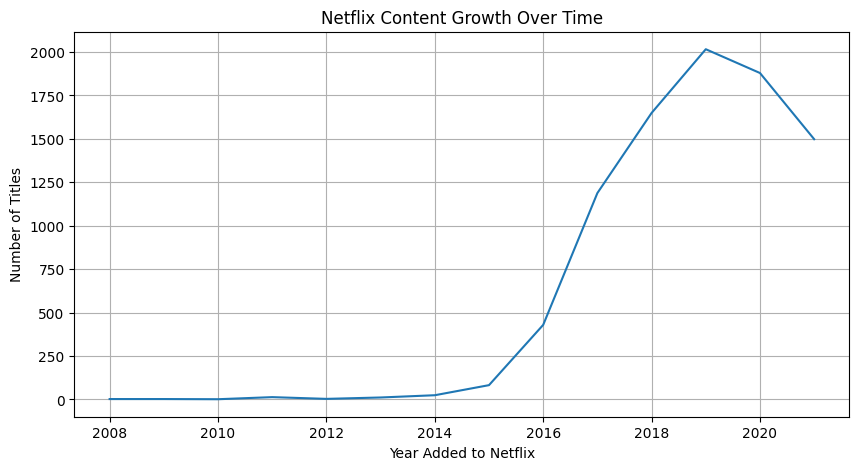

In [0]:
# Check column names to find release or date-added column
print(df.columns)

# Convert 'release_year' or 'date_added' to datetime (if exists)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract the year
df['year_added'] = df['date_added'].dt.year

# Count number of titles per year
content_per_year = df['year_added'].value_counts().sort_index()

# Plot content growth
plt.figure(figsize=(10,5))
sns.lineplot(x=content_per_year.index, y=content_per_year.values)
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()


/home/spark-47dfd324-18f2-4a13-be96-9c/.ipykernel/8439/command-4733576494167031-3772558685:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='content_type', data=df, palette='pastel')


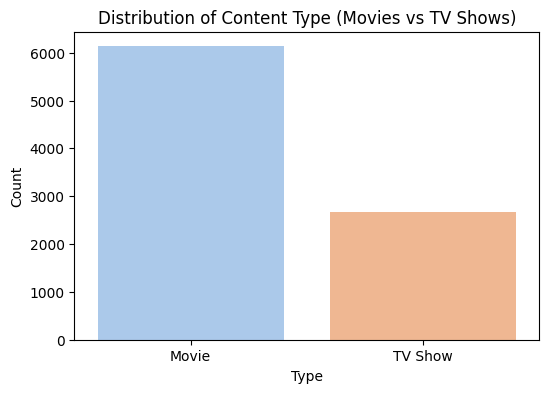

In [0]:
plt.figure(figsize=(6,4))
sns.countplot(x='content_type', data=df, palette='pastel')
plt.title("Distribution of Content Type (Movies vs TV Shows)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


/home/spark-47dfd324-18f2-4a13-be96-9c/.ipykernel/8439/command-4733576494167032-1976037810:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index, palette='cool')


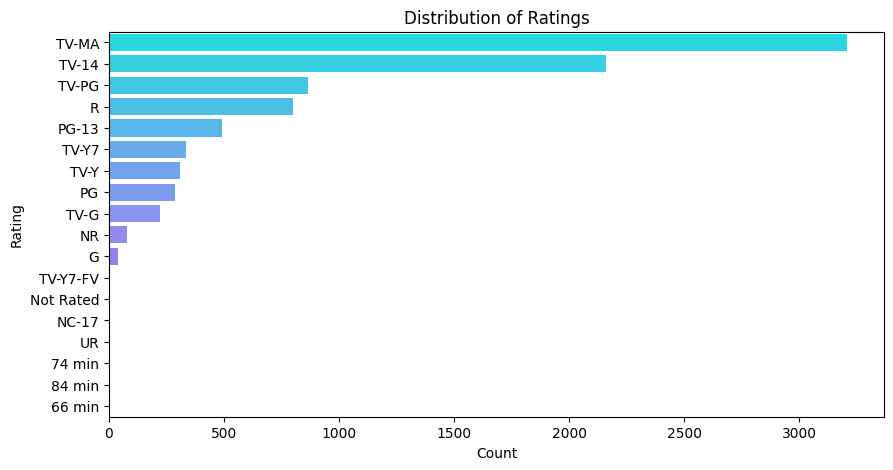

In [0]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index, palette='cool')
plt.title("Distribution of Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()


/home/spark-47dfd324-18f2-4a13-be96-9c/.ipykernel/8439/command-4733576494167033-3202730361:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=top_genres, palette='magma')


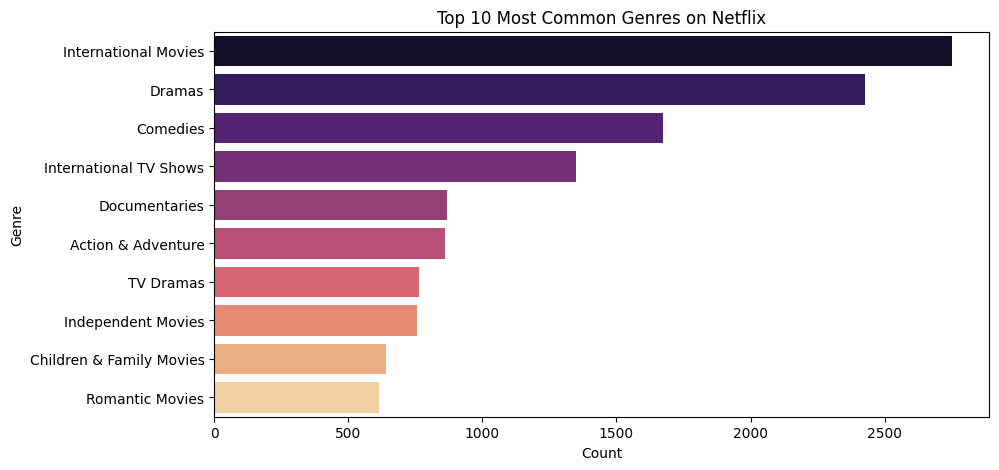

In [0]:
# Some rows may have multiple genres separated by commas
df['genres'] = df['genres'].astype(str)

# Split and count
from collections import Counter
genre_list = df['genres'].str.split(', ')
genres = [g for sublist in genre_list for g in sublist]
top_genres = pd.DataFrame(Counter(genres).most_common(10), columns=['Genre', 'Count'])

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x='Count', y='Genre', data=top_genres, palette='magma')
plt.title("Top 10 Most Common Genres on Netflix")
plt.show()


/home/spark-47dfd324-18f2-4a13-be96-9c/.ipykernel/8439/command-4733576494167034-354332219:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Country', data=top_countries, palette='viridis')


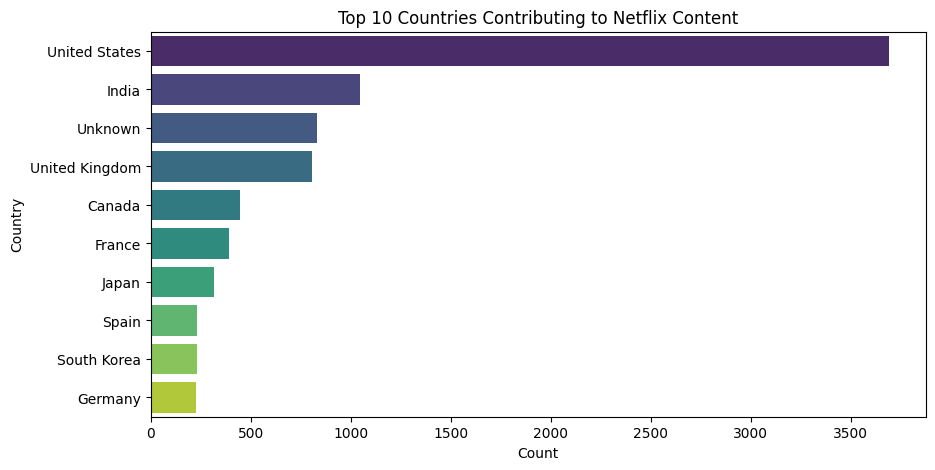

In [0]:
df['country'] = df['country'].astype(str)
country_list = df['country'].str.split(', ')
countries = [c for sublist in country_list for c in sublist]
top_countries = pd.DataFrame(Counter(countries).most_common(10), columns=['Country', 'Count'])

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x='Count', y='Country', data=top_countries, palette='viridis')
plt.title("Top 10 Countries Contributing to Netflix Content")
plt.show()


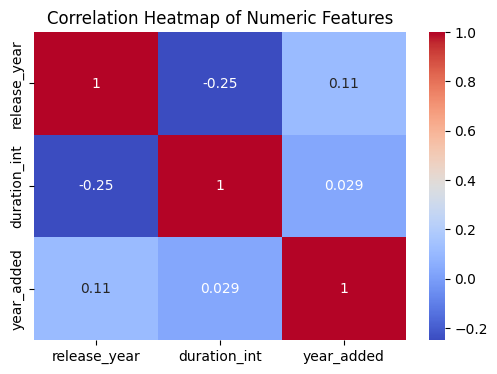

In [0]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


Red / Dark Orange	Strong Positive Correlation	e.g. release_year ↑ → year_added ↑

🔵 Blue / Dark Purple	Strong Negative Correlation	e.g. duration_int ↓ → year_added ↑

⚪ White / Light Colors	Weak or No Correlation

FEATURE ENGINEERING

In [0]:
def categorize_duration(row):
    if row['duration_type'] == 'min':  # For Movies
        if row['duration_int'] < 60:
            return 'Short'
        elif 60 <= row['duration_int'] <= 120:
            return 'Medium'
        else:
            return 'Long'
    elif row['duration_type'] == 'Season':  # For TV Shows
        if row['duration_int'] == 1:
            return 'Single Season'
        else:
            return 'Multi Season'
    else:
        return 'Unknown'

df['Content_Length_Category'] = df.apply(categorize_duration, axis=1)


In [0]:
def label_original(row):
    title = str(row['title']).lower()
    description = str(row.get('description', '')).lower()
    if 'netflix' in title or 'netflix' in description:
        return 'Netflix Original'
    else:
        return 'Licensed'

df['Original_vs_Licensed'] = df.apply(label_original, axis=1)


In [0]:
df[['title', 'duration_int', 'duration_type', 'Content_Length_Category', 'Original_vs_Licensed']]


,title,duration_int,duration_type,Content_Length_Category,Original_vs_Licensed
0,Dick Johnson Is Dead,90.0,min,Medium,Licensed
1,Blood & Water,2.0,Season,Multi Season,Licensed
2,Ganglands,1.0,Season,Single Season,Licensed
3,Jailbirds New Orleans,1.0,Season,Single Season,Licensed
4,Kota Factory,2.0,Season,Multi Season,Licensed
...,...,...,...,...,...
8802,Zodiac,158.0,min,Long,Licensed
8803,Zombie Dumb,2.0,Season,Multi Season,Licensed
8804,Zombieland,88.0,min,Medium,Licensed
8805,Zoom,88.0,min,Medium,Licensed


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="pastel")

/home/spark-47dfd324-18f2-4a13-be96-9c/.ipykernel/8439/command-4697486304876533-2403496366:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Content_Length_Category', data=df, palette='coolwarm')


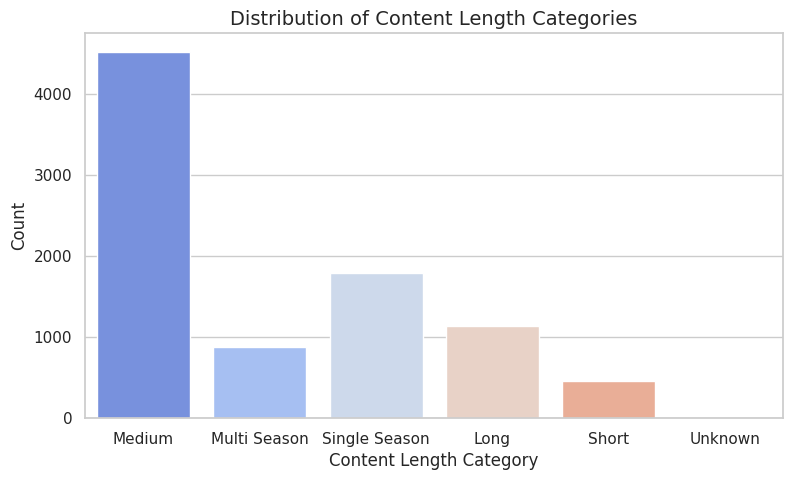

In [0]:
plt.figure(figsize=(9,5))
sns.countplot(x='Content_Length_Category', data=df, palette='coolwarm')
plt.title('Distribution of Content Length Categories', fontsize=14)
plt.xlabel('Content Length Category')
plt.ylabel('Count')
plt.show()


/home/spark-47dfd324-18f2-4a13-be96-9c/.ipykernel/8439/command-4697486304876534-1387335591:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Original_vs_Licensed', data=df, palette='viridis')


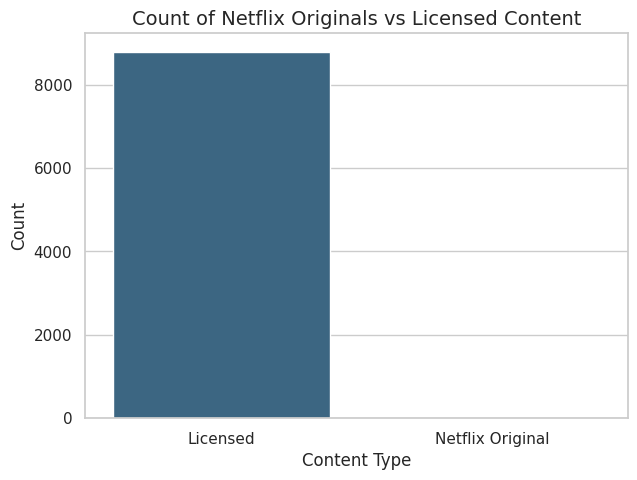

In [0]:
plt.figure(figsize=(7,5))
sns.countplot(x='Original_vs_Licensed', data=df, palette='viridis')
plt.title('Count of Netflix Originals vs Licensed Content', fontsize=14)
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()


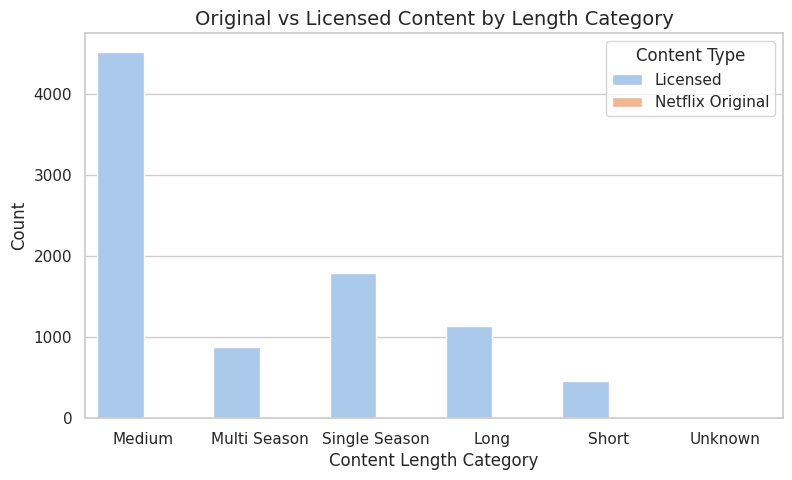

In [0]:
plt.figure(figsize=(9,5))
sns.countplot(x='Content_Length_Category', hue='Original_vs_Licensed', data=df)
plt.title('Original vs Licensed Content by Length Category', fontsize=14)
plt.xlabel('Content Length Category')
plt.ylabel('Count')
plt.legend(title='Content Type')
plt.show()


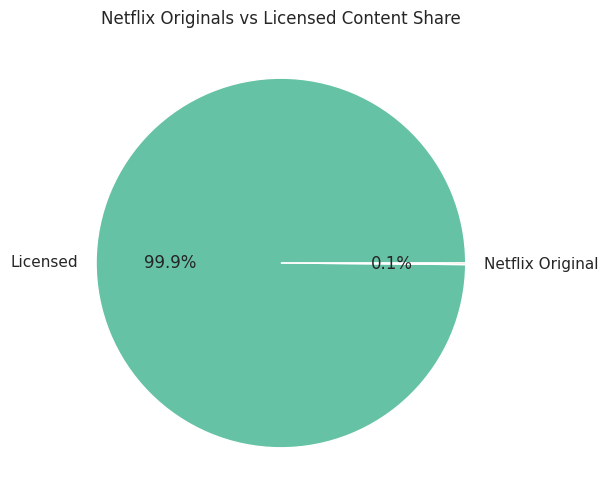

In [0]:
counts = df['Original_vs_Licensed'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Netflix Originals vs Licensed Content Share')
plt.show()


In [0]:

df.to_csv(f"{download_path}/netflix_feature_engineeredned.csv", index=False)


CLUSTERING

In [0]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.cluster import KMeans

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff5680e38400>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'


In [0]:
df_read=pd.read_csv(download_path+"/netflix_feature_engineeredned.csv")

In [0]:
df_read

,show_id,content_type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,duration_int,duration_type,year_added,Content_Length_Category,Original_vs_Licensed
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,2021.0,Medium,Licensed
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Season,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Season,2021.0,Multi Season,Licensed
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season,2021.0,Single Season,Licensed
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season,2021.0,Single Season,Licensed
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Season,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Season,2021.0,Multi Season,Licensed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158.0,min,2019.0,Long,Licensed
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Season,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2.0,Season,2019.0,Multi Season,Licensed
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88.0,min,2019.0,Medium,Licensed
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88.0,min,2020.0,Medium,Licensed


In [0]:

# 1️⃣ Prepare genre features
mlb = MultiLabelBinarizer()
genres = df_read['genres'].astype(str).str.split(', ')
genre_features = mlb.fit_transform(genres)

# 2️⃣ Prepare duration feature
def extract_duration(row):
    if row['content_type'] == 'Movie':
        try:
            return int(str(row['duration']).split(' ')[0])
        except:
            return 0
    elif row['content_type'] == 'TV Show':
        try:
            return int(str(row['duration']).split(' ')[0]) * 60  # Approximation: 1 season = 60 min
        except:
            return 0
    else:
        return 0

duration_feature = df_read.apply(extract_duration, axis=1).values.reshape(-1, 1)

# 3️⃣ Prepare rating feature
rating_map = {k: v for v, k in enumerate(df_read['rating'].dropna().unique())}
rating_feature = df_read['rating'].map(rating_map).fillna(0).values.reshape(-1, 1)

# 4️⃣ Combine features
X = np.hstack([genre_features, duration_feature, rating_feature])

# 5️⃣ Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6️⃣ Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_read['cluster'] = kmeans.fit_predict(X_scaled)

# 7️⃣ View results
display(df_read[['title', 'genres', 'duration', 'rating', 'cluster']].head(20))

# 8️⃣ Optional: Check cluster counts
print(df_read['cluster'].value_counts())


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff5684e9eca0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

title,genres,duration,rating,cluster
Dick Johnson Is Dead,Documentaries,90 min,PG-13,4
Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",2 Season,TV-MA,3
Ganglands,"Crime TV Shows, International TV Shows, TV Action & Adventure",1 Season,TV-MA,3
Jailbirds New Orleans,"Docuseries, Reality TV",1 Season,TV-MA,2
Kota Factory,"International TV Shows, Romantic TV Shows, TV Comedies",2 Season,TV-MA,3
Midnight Mass,"TV Dramas, TV Horror, TV Mysteries",1 Season,TV-MA,3
My Little Pony: A New Generation,Children & Family Movies,91 min,PG,0
Sankofa,"Dramas, Independent Movies, International Movies",125 min,TV-MA,1
The Great British Baking Show,"British TV Shows, Reality TV",9 Season,TV-14,2
The Starling,"Comedies, Dramas",104 min,PG-13,1


1    3579
0    2127
3    1362
4    1118
2     621
Name: cluster, dtype: int64


In [0]:
df_read.groupby('cluster')['genres'].apply(lambda x: ', '.join(x.head(5)))


cluster
0    Children & Family Movies, Thrillers, Children ...
1    Dramas, Independent Movies, International Movi...
2    Docuseries, Reality TV, British TV Shows, Real...
3    International TV Shows, TV Dramas, TV Mysterie...
4    Documentaries, Documentaries, International Mo...
Name: genres, dtype: object

/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


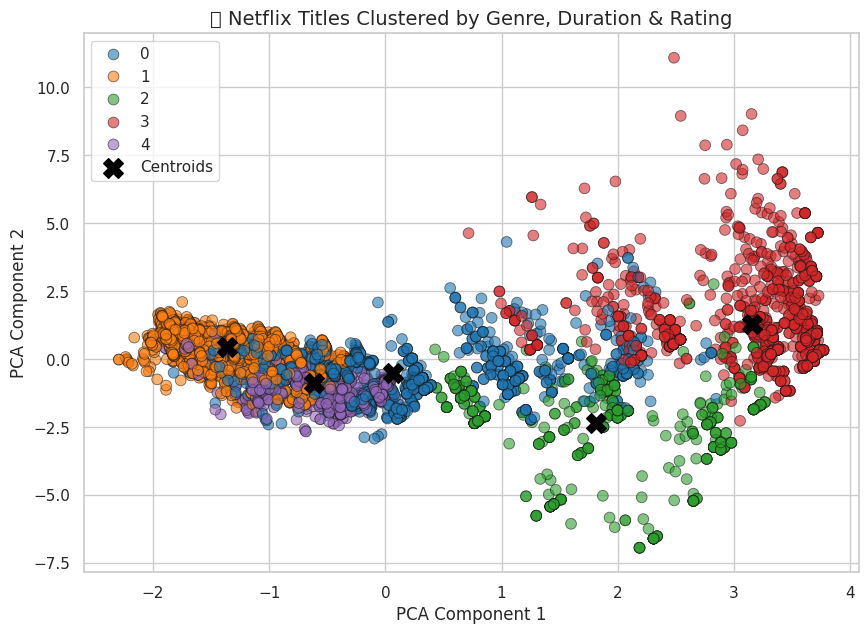

In [0]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce data to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA results to DataFrame
df_read['PCA1'] = X_pca[:, 0]
df_read['PCA2'] = X_pca[:, 1]

# Plot the clusters using seaborn for better visuals
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='cluster',
    palette='tab10',
    data=df_read,
    alpha=0.6,
    s=60,
    edgecolor='k'
)

# Plot centroids
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 0], centers[:, 1],
    c='black', s=200, marker='X', label='Centroids'
)

plt.title('🎬 Netflix Titles Clustered by Genre, Duration & Rating', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()


CLASSIFICATION

In [0]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [0]:
df_features = df_read.copy()


In [0]:
# Convert duration text to numbers
df_features['duration'] = (
    df_features['duration'].str.extract(r'(\d+)').astype(float).fillna(0)
)


In [0]:
if 'content_age_years' in df_features.columns:
    df_features['content_age_years'] = df_features['content_age_years'].fillna(0)
else:
    df_features['content_age_years'] = 0  # fallback


In [0]:
# Take the first genre (primary)
df_features['primary_genre'] = df_features['genres'].str.split(',').str[0]

# Encode genre and rating
df_features['primary_genre'] = df_features['primary_genre'].astype('category').cat.codes
df_features['rating'] = df_features['rating'].astype('category').cat.codes


In [0]:
feature_cols = ['duration', 'rating', 'content_age_years', 'primary_genre']
X = df_features[feature_cols]

# Encode target: Movie = 0, TV Show = 1
y = df_features['content_type'].map({'Movie': 0, 'TV Show': 1})


In [0]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [0]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [0]:
y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762

Accuracy: 1.0


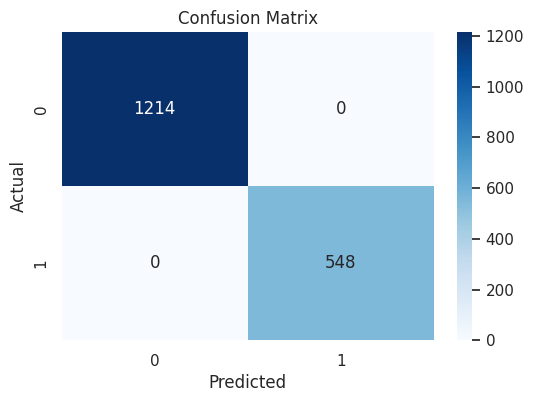

In [0]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


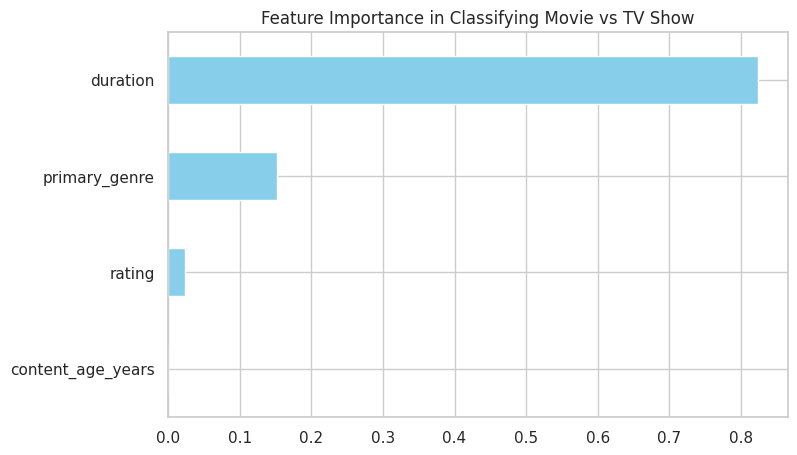

In [0]:
# Check Feature Importance (Which Features Matter Most?)
importances = pd.Series(clf.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', figsize=(8,5), color='skyblue')
plt.title('Feature Importance in Classifying Movie vs TV Show')
plt.show()
